In [1]:
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

from astropy.io import fits
from astropy.constants import c
from astropy.table import QTable

import pyimfit
import pandas as pd

import argparse
from pathlib import Path

import astropy.units as u
import subprocess
import traceback as tb
import sys
import json

from parse_results import *
from astropy.visualization import quantity_support

In [2]:

master_table = QTable.read("/home/ryans/Projects/Photometric Decomp/Analysis/master_table.csv", data_start=2)
master_table["NAME"] = master_table['\ufeffNAME']
master_table = master_table.to_pandas()

In [3]:
p = Path("/home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/")
SGAtable = QTable.read(os.path.join("/home/ryans/Projects/Photometric Decomp/Analysis/", "SGA-2020.fits"), format="fits", hdu=1)
TRACTOR = QTable.read(os.path.join("/home/ryans/Projects/Photometric Decomp/Analysis/", "SGA-2020.fits"), format="fits", hdu=2)
# master_table = astropy.io.ascii.read("/home/ryans/Projects/Photometric Decomp/Analysis/master_table.csv")
galmarks = json.load(open(os.path.join(p, "galmarks.json")))

total_bad_fit = 0
total_fit = 0
bound_sticking = 0

galaxies = []
bands = ["g", "r"]

structure = os.walk(p)
for root, dirs, files in structure:
    if len(glob.glob(os.path.join(root,"*.fits"))) != 0: # Check to see if we have entered a folder with galaxy data
        galaxies.append([Path(root).resolve(), os.path.basename(os.path.dirname(root))])

fit_type = "2_sersic"

all_results =  get_all_results(galaxies, bands, fit_type, galmarks)
total_fit = len(all_results.groups.indices)-1

thresh = 1
total_bad_fit = len(all_results[all_results["Reduced ChiSq"] > thresh].groups.indices)

print(f"Total fit: {total_fit}")
print(f"Total poor fit: {total_bad_fit} ({total_bad_fit/total_fit * 100:.2f}% bad)")
print(f"Total parameter bounds sticking: {bound_sticking}")

Total fit: 169
Total poor fit: 2 (1.18% bad)
Total parameter bounds sticking: 0


In [4]:
all_results

Galaxy Name,Galaxy Type,Fit Function,Function Label,band,b/a,Flux Ratio,Flux,ChiSq,Reduced ChiSq,Fit Status,Fit Status Message,I_e,I_e_unc,PA,PA_unc,ell,ell_unc,n,n_unc,r_e,r_e_unc
str24,str2,str6,str5,str1,float64,float64,float64,float64,float64,str1,str58,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2MASSJ22443540-0101516,PR,Sersic,Host,g,0.94282,0.94997,48.485,21149.278563,0.882802,1,SUCCESS: Convergence in fit-statistic value.,0.157039,nan,117.773,nan,0.05718,nan,5.66406,nan,3.49345,nan
2MASSJ22443540-0101516,PR,Sersic,Polar,g,0.11301000000000005,0.05003,2.5535,21149.278563,0.882802,1,SUCCESS: Convergence in fit-statistic value.,0.00416559,nan,87.5025,nan,0.88699,nan,0.0508572,nan,21.1651,nan
2MASSJ22443540-0101516,PR,Sersic,Host,r,0.94282,0.93672,106.07,23576.075572,0.984059,1,SUCCESS: Convergence in fit-statistic value.,0.253239,nan,117.773,nan,0.05718,nan,4.70819,nan,4.25608,nan
2MASSJ22443540-0101516,PR,Sersic,Polar,r,0.11301000000000005,0.06328,7.1661,23576.075572,0.984059,1,SUCCESS: Convergence in fit-statistic value.,0.0110024,nan,87.5025,nan,0.88699,nan,0.37989,nan,26.4276,nan
2MASXJ00012375-0051067,PR,Sersic,Host,g,0.359252,0.58901,99.811,84177.301365,0.955106,1,SUCCESS: Convergence in fit-statistic value.,0.273655,nan,21.5049,nan,0.640748,nan,1.81705,nan,8.06668,nan
2MASXJ00012375-0051067,PR,Sersic,Polar,g,0.38184399999999996,0.41099,69.645,84177.301365,0.955106,1,SUCCESS: Convergence in fit-statistic value.,0.00758228,nan,44.009,nan,0.618156,nan,0.142145,nan,60.3496,nan
2MASXJ00012375-0051067,PR,Sersic,Host,r,0.325101,0.68938,255.12,93978.106793,1.066309,1,SUCCESS: Convergence in fit-statistic value.,0.712984,nan,21.4406,nan,0.674899,nan,2.47835,nan,7.81227,nan
2MASXJ00012375-0051067,PR,Sersic,Polar,r,0.37899700000000003,0.31062,114.95,93978.106793,1.066309,1,SUCCESS: Convergence in fit-statistic value.,0.012309,nan,45.3352,nan,0.621003,nan,0.192037,nan,59.5847,nan
2MASXJ00175178+1516331,PR,Sersic,Host,g,0.598024,0.81638,137.61,38397.741056,0.80593,1,SUCCESS: Convergence in fit-statistic value.,0.165756,nan,87.8839,nan,0.401976,nan,3.11832,nan,8.30831,nan


In [5]:
pixscale = 0.262 * u.arcsec

In [6]:
def nmgyfluxSB_to_magSB(fluxSB):
    zero_point_star_equiv = u.zero_point_flux(3631.1 * u.Jy)
    return (fluxSB*u.arcsec**2).to(u.mag("AB"), zero_point_star_equiv).value * u.mag("AB/arcsec**2")

def nmgymagSB_to_fluxSB(magSB):
    zero_point_star_equiv = u.zero_point_flux(3631.1 * u.Jy)
    return (magSB.value*u.ABmag).to(u.nmgy, zero_point_star_equiv).value * u.nmgy/u.arcsec**2

# x = 22.5 * u.mag("AB/arcsec**2")
# nmgyfluxSB_to_magSB(nmgymagSB_to_fluxSB(x))

## Plotting

In [7]:
type_colors = {
    "PR": "red",
    "PB": "green",
    "PH": "blue"
}
type_ls = {
    "PR": "-",
    "PB": "--",
    "PH": "-."
}
gal_types = ["PR", "PH", "PB"]
linewidth = 1.5
dpi = 300

### Flux or Luminosity Ratio

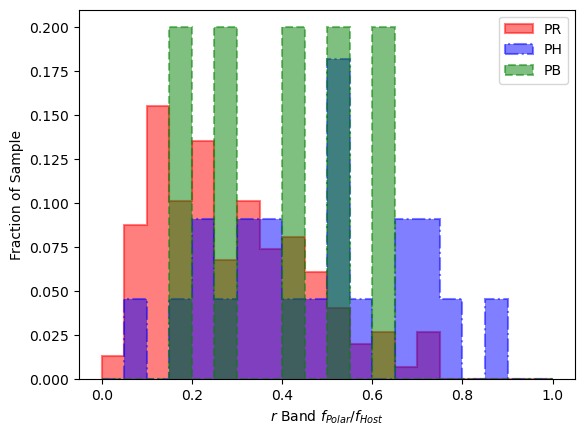

In [8]:
# a = all_results[all_results["Function Label"] == "Host"]
# plt.hist(a["Flux Ratio"])
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

for gal_type in gal_types:
    a = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    bins = np.arange(0, 1 + 0.05, 0.05)
    val, bins = np.histogram(a["Flux Ratio"], bins=bins)
    plt.stairs(val/len(a), edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=gal_type, linewidth=linewidth, fill=True, alpha=0.5)

plt.xlabel(r"$r$ Band ${f_{Polar}}/{f_{Host}}$")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

In [9]:
master_table.columns
print([i for i in master_table.columns])

['\ufeffNAME', 'IAU_ID', 'ALT_NAME', 'RA', 'DEC', 'PSG_TYPE_1', 'PSG_TYPE_2', 'CATEGORY_1', 'CATEGORY_2', 'MORPHTYPE', 'EGIS', 'EGIPS', 'REFERENCE', 'LINKS', 'PGC', 'RA_LEDA', 'DEC_LEDA', 'MORPHTYPE_LEDA', 'D25_LEDA', 'REDSHIFT_LEDA', 'NED_NAME', 'REDSHIFT_NED', 'J_MAG_NED', 'H_MAG_NED', 'Ks_MAG_NED', 'SGA_ID', 'RA_SGA', 'DEC_SGA', 'G_MAG_SB26_SGA', 'G_MAG_SB26_ERR_SGA', 'R_MAG_SB26_SGA', 'R_MAG_SB26_ERR_SGA', 'Z_MAG_SB26_SGA', 'Z_MAG_SB26_ERR_SGA', 'D26_SGA', 'D26_REF', 'PHDEP_G', 'PHDEP_R', 'PHDEP_I', 'PHDEP_Z', 'PHDEP_GR', 'PHDEP_ALL', 'G_MAG_ASYM_IRAF', 'G_MAG_ASYM_ERR_IRAF', 'G_MAG_SB26_IRAF', 'R26_G_IRAF', 'R26_G_ERR_IRAF', 'G_MAG_OUTER_IRAF', 'R_G_IRAF', 'R_MAG_ASYM_IRAF', 'R_MAG_ASYM_ERR_IRAF', 'R_MAG_SB26_IRAF', 'R26_R_IRAF', 'R26_R_ERR_IRAF', 'R_MAG_OUTER_IRAF', 'R_R_IRAF', 'I_MAG_ASYM_IRAF', 'I_MAG_ASYM_ERR_IRAF', 'I_MAG_SB26_IRAF', 'R26_I_IRAF', 'R26_I_ERR_IRAF', 'I_MAG_OUTER_IRAF', 'R_I_IRAF', 'Z_MAG_ASYM_IRAF', 'Z_MAG_ASYM_ERR_IRAF', 'Z_MAG_SB26_IRAF', 'R26_Z_IRAF', 'R26_

### Abs mag

In [10]:
from astropy.cosmology import Planck18, WMAP9
import numpy as np

cosmo = Planck18

$m-M = 5\log d -5 + A + K_{Corr}$

$m-M_{Corr} = 5\log d -5 - A - K_{Corr}$

$M_{Corr} = M - A - K_{Corr}$

In [11]:
all_results.groups

<TableGroups indices=[  0   4   8  12  16  20  24  28  36  40  44  48  52  56  60  64  68  72
  76  80  84  88  92  96 100 104 108 112 116 120 124 128 132 136 140 144
 152 156 160 164 168 172 176 180 184 188 192 196 200 204 208 212 216 220
 224 228 232 236 240 244 248 252 256 260 264 268 272 276 280 284 288 292
 296 300 304 308 312 316 320 324 328 332 336 340 344 348 352 356 360 368
 372 376 380 384 388 392 400 404 408 412 416 420 424 428 432 436 440 444
 448 452 456 460 464 472 476 480 484 488 492 496 500 504 508 512 516 524
 528 532 536 540 544 548 552 556 560 564 568 572 576 580 584 588 592 596
 600 604 608 612 616 620 624 628 632 636 640 644 648 652 656 660 664 668
 672 676 680 684 688 692 696 700]>

In [12]:
DLs = []
DAs = []
zs = []
scales = []
K_Corr_gs = []
K_Corr_rs = []
A_gs = []
A_rs = []

for galaxy_name in all_results["Galaxy Name"]:
    tab = master_table[master_table["NAME"] == galaxy_name].iloc[0]
    DLs.append(tab["DL"])
    DAs.append(tab["DA"])
    zs.append(tab["REDSHIFT"])
    scales.append(tab["SCALE"])
    K_Corr_gs.append(tab["KCOR_G"])
    K_Corr_rs.append(tab["KCOR_R"])
    A_gs.append(tab["A_G"])
    A_rs.append(tab["A_R"])
    # if len(tab) == 0:
    #     print(tab)

all_results["DL"] = np.array(DLs) * u.Mpc
all_results["DA"] = np.array(DAs) * u.Mpc
all_results["z"] = np.array(zs, dtype=np.float64)
all_results["Scale"] = np.array(scales) * u.kpc/u.arcsec

A_gs = np.array(A_gs) 
A_rs = np.array(A_rs) 
K_Corr_gs = np.array(K_Corr_gs) 
K_Corr_rs = np.array(K_Corr_rs) 
tablen = len(all_results)
all_results["KCOR"] = np.zeros(tablen) 
all_results["A"] = np.zeros(tablen) 

band_m = all_results["band"] == "g"
all_results["KCOR"][band_m] = K_Corr_gs[band_m]
all_results["A"][band_m] = A_gs[band_m]
band_m = all_results["band"] == "r"
all_results["KCOR"][band_m] = K_Corr_rs[band_m]
all_results["A"][band_m] = A_rs[band_m]

all_results["App Mag"] = flux2ABmag(all_results["Flux"]*u.nmgy).value
all_results["Abs Mag"] = all_results["App Mag"] - astropy.coordinates.Distance(all_results["DL"]).distmod.value

all_results["Abs Mag Corr"] = all_results["Abs Mag"] - A_gs - K_Corr_gs
all_results = all_results[np.isfinite(all_results["DL"])]
all_results = all_results.group_by("Galaxy Name")

In [13]:
SGAtable.columns
m = (SGAtable["Z_LEDA"] > 0) & (SGAtable["R_MAG_SB26"] != -1)
m2 = (SGAtable["Z_LEDA"] > 0) & (SGAtable["G_MAG_SB26"] != -1)


SGAtable["R_ABSMAG_SB26"] = -1*np.ones(len(SGAtable))
SGAtable["G_ABSMAG_SB26"] = -1*np.ones(len(SGAtable))

SGAtable["R_ABSMAG_SB26"][m] = (SGAtable["R_MAG_SB26"][m] *u.mag - cosmo.distmod(SGAtable["Z_LEDA"][m])).value
SGAtable["G_ABSMAG_SB26"][m2] = (SGAtable["G_MAG_SB26"][m2] *u.mag - cosmo.distmod(SGAtable["Z_LEDA"][m2])).value

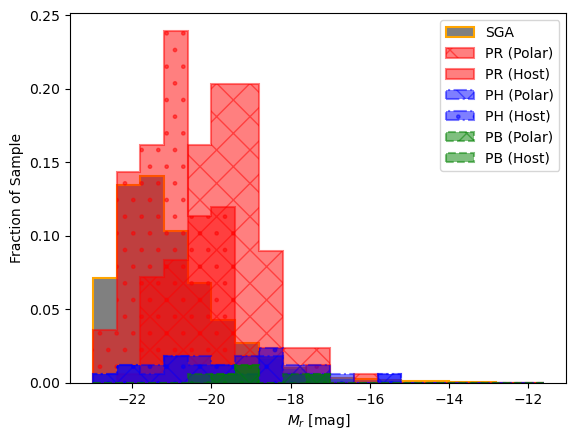

In [14]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-23, -12)
step = 0.6
bins = np.arange(r[0], r[1]+step, step) * u.ABmag

sgaval, bins = np.histogram(SGAtable["R_ABSMAG_SB26"] * u.ABmag, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_absmag = polar["Abs Mag"]
    host_absmag = host["Abs Mag"]


    polval, bins = np.histogram(polar_absmag, bins=bins)
    plt.stairs(polval/ngals, edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.5, hatch="X")

    hostval, bins = np.histogram(host_absmag, bins=bins)
    plt.stairs(hostval/ngals, edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.5, hatch=".")


plt.xlabel(r"$M_r$ [mag]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

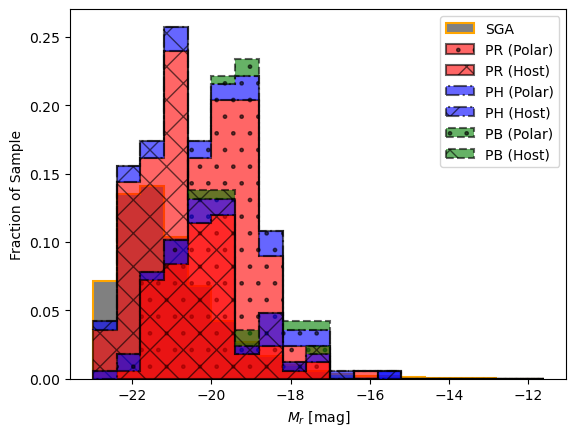

In [15]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-23, -12)
step = 0.6
bins = np.arange(r[0], r[1]+step, step) * u.ABmag

sgaval, bins = np.histogram(SGAtable["R_ABSMAG_SB26"] * u.ABmag, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

polar_absmags = []

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_absmag = polar["Abs Mag"]
    polar_absmags.append(polar_absmag)
    host_absmag = host["Abs Mag"]


    polval, bins = np.histogram(polar_absmag, bins=bins)
    plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    baseline_polar += polval/ngals

    hostval, bins = np.histogram(host_absmag, bins=bins)
    plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    baseline_host += hostval/ngals

# plt.hist(polar_absmags, stacked=True, label=gal_types, color=[type_colors[gal_type] for gal_type in gal_types])
plt.xlabel(r"$M_r$ [mag]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

### 26th isophote radius

In [16]:
import scipy

In [17]:
def radius_of_isophote(mu_iso, mu_eff, n, r_eff):
    b_n = scipy.special.gammaincinv(2*n, 0.5)
    I_iso = nmgymagSB_to_fluxSB(mu_iso)
    I_eff = nmgymagSB_to_fluxSB(mu_eff)
    return r_eff * ((b_n-np.log(I_iso/I_eff))/b_n)**n

In [18]:

# Example: radius of the 26 mag/arcsec^2 isophote
mu_26 = 26* u.mag("AB/arcsec**2")
mu_e = 27* u.mag("AB/arcsec**2")  # example effective surface brightness
n = 0.2
r_e = 60
r_26 = radius_of_isophote(mu_26, mu_e, n, r_e)
print(f"r_26 (semi-major axis) = {r_26:.2f}")

# quantity_support()
# plt.imshow(model(xx,yy), extent=(x[0],x[-1], y[0], y[-1]))

r_26 (semi-major axis) = nan


/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [19]:
all_results["mu_eff"] = nmgyfluxSB_to_magSB(all_results["I_e"] * u.nmgy/pixscale**2)
all_results["R26"] = radius_of_isophote(26*u.ABmag, all_results["mu_eff"], all_results["n"], all_results["r_e"]) * u.pix
all_results["R26"] = all_results["R26"].to(u.arcsec, equivalencies=u.pixel_scale(1*u.pix/(0.262*u.arcsec)))
all_results["R26"] = all_results["R26"]*all_results["Scale"]

m = (SGAtable["Z_LEDA"] >0) & (SGAtable["SMA_SB26"] != -1)
sga_sma_SB26_real = 1/cosmo.arcsec_per_kpc_proper(SGAtable["Z_LEDA"][m])*SGAtable["SMA_SB26"][m]*u.arcsec
# print(all_results["R26","n", "mu_eff"][all_results["R26"] != all_results["R26"]])

/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [20]:
# print(all_results["Scale","z"])
# print(cosmo.arcsec_per_kpc_proper(all_results["z"][np.isfinite(all_results["z"])]))
# print(1/cosmo.arcsec_per_kpc_proper(all_results["z"][all_results["z"]>0]))

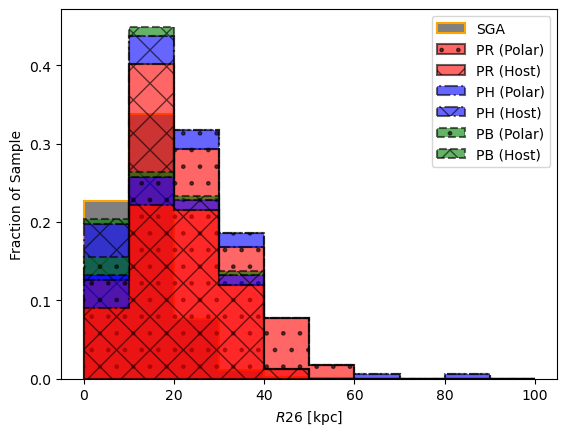

In [21]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (0, 100)
step = 10
bins = np.arange(r[0], r[1]+step, step) * u.kpc

sgaval, bins = np.histogram(sga_sma_SB26_real/2, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_r26 = polar["R26"]
    host_r26 = host["R26"]


    polval, bins = np.histogram(polar_r26, bins=bins)
    plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    baseline_polar += polval/ngals

    hostval, bins = np.histogram(host_r26, bins=bins)
    plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    baseline_host += hostval/ngals

plt.xlabel(r"$R26$ [kpc]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

### Luminosity Ratio of Components

In [22]:
def SersicFlux(I_e, r_e, n, ell):
    b_n = scipy.special.gammaincinv(2*n, 0.5)
    q = 1-ell
    L = 2*np.pi*n*np.exp(b_n)*I_e*(r_e**2)
    return q*L*scipy.special.gamma(2*n)/(b_n**(2*n))

In [23]:
all_results["Flux2"] = SersicFlux(all_results["I_e"]*u.nmgy/pixscale**2, (all_results["r_e"]*u.pix).to(u.arcsec, equivalencies=u.pixel_scale(1*u.pix/(0.262*u.arcsec))), all_results["n"], all_results["ell"])
# all_results["Flux"] = all_results["Flux"] * u.nmgy

In [24]:
# print(all_results["Flux", "Flux2"])

In [25]:
# quantity_support()
# fig = plt.Figure(dpi=dpi)
# ngals = np.size(np.unique(all_results["Galaxy Name"]))

# r = (0, 100)
# step = 10
# bins = np.arange(r[0], r[1]+step, step) 

# sgaval, bins = np.histogram(sga_sma_SB26_real/2, bins=bins)
# # plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

# baseline_host = np.zeros(np.size(bins)-1)
# baseline_polar = np.zeros(np.size(bins)-1)
# for gal_type in gal_types:
#     polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
#     host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
#     # z = master_table["Z"]
#     polar_flux = 
#     host_r26 = host["R26"]


#     polval, bins = np.histogram(polar_r26, bins=bins)
#     plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
#     baseline_polar += polval/ngals

#     hostval, bins = np.histogram(host_r26, bins=bins)
#     plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
#     baseline_host += hostval/ngals

# plt.xlabel(r"$L_{PS}/L_{Host}$")
# plt.ylabel("Fraction of Sample")
# plt.legend()
# plt.show()

### Check with Photutils
Actually photutils seems to produce a generally worse result, but I think my alg works

In [26]:
model = astropy.modeling.functional_models.Sersic2D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=0.2, ellip=0.7)

sz = 100
x = np.linspace(-sz,sz,sz)
y = np.linspace(-sz,sz,sz)
xx,yy = np.meshgrid(x,y) 

In [27]:
from photutils.isophote import EllipseGeometry
geometry = EllipseGeometry(x0=sz/2, y0=sz/2, sma=20, eps=0.5,
                           pa=np.deg2rad(0))

/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<matplotlib.patches.Ellipse at 0x7f8558efeba0>,)

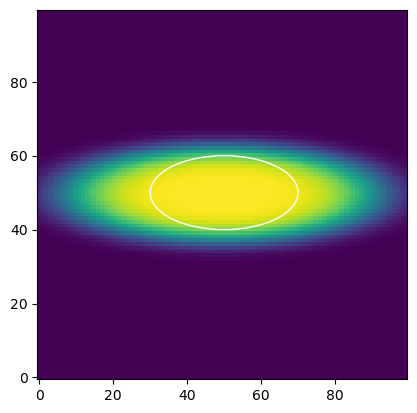

In [28]:
from photutils.aperture import EllipticalAperture
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          theta=geometry.pa)
fig, ax = plt.subplots()
ax.imshow(model(xx,yy), origin='lower')
aper.plot(color='white')

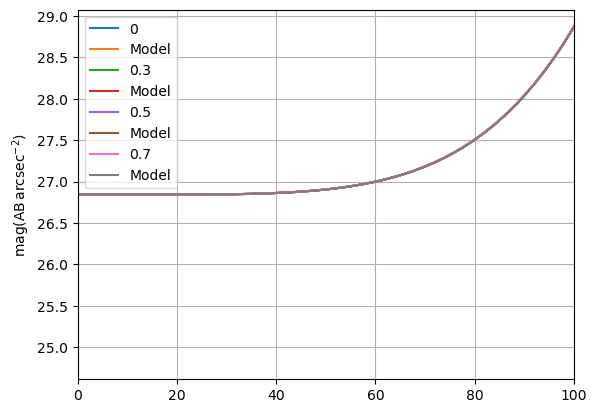

In [29]:
for ellip in [0, 0.3, 0.5, 0.7]:
    model = astropy.modeling.functional_models.Sersic2D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=0.2, ellip=ellip)
    model2 = astropy.modeling.functional_models.Sersic1D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=0.2)

    sz = 100
    x = np.linspace(-sz,sz,sz)
    y = np.linspace(-sz,sz,sz)
    xx,yy = np.meshgrid(x,y) 

    plt.plot(x, nmgyfluxSB_to_magSB(model(xx,yy)[int(sz/2),:] * u.nmgy/u.arcsec**2), label=ellip)
    # plt.plot(model(xx,yy)[:,int(sz/2)], label=ellip)
    plt.plot(x, nmgyfluxSB_to_magSB(model2(x) * u.nmgy/u.arcsec**2), label="Model")
plt.xlim([0,100])
# plt.axvline(r_26_2)
plt.grid()
plt.legend()
plt.show()

In [30]:
from photutils.isophote import Ellipse
ellipse = Ellipse(model(xx,yy), geometry=geometry)
try:
    isolist = ellipse.fit_image()
    t = isolist.to_table()
    t["mag"] = nmgyfluxSB_to_magSB(t["intens"] * u.nmgy/u.arcsec**2)
    # t["mag","sma"][:50]
    from photutils.isophote import build_ellipse_model
    model_image = build_ellipse_model(model(xx,yy).shape, isolist)
    plt.imshow(model_image)
    smas = np.linspace(10, 50, 5)
    for sma in smas:
        iso = isolist.get_closest(sma)
        x, y, = iso.sampled_coordinates()
        plt.plot(x, y, color='white')
except:
    isolist = None

/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/photutils/isophote/fitter.py:355: RuntimeWarning: divide by zero encountered in scalar divide
  correction = harmonic * 2.0 * (1.0 - eps) / sma / gradient
/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/photutils/isophote/geometry.py:294: RuntimeWarning: invalid value encountered in scalar divide
  return (self.sma * (1.0 - self.eps)


### $g-r$ Color

(array([  1.,   0.,   3.,   9., 113., 202.,  12.,   4.,   1.,   1.]),
 array([-1.37771435, -0.95870656, -0.53969877, -0.12069098,  0.2983168 ,
         0.71732459,  1.13633238,  1.55534017,  1.97434796,  2.39335575,
         2.81236354]),
 <BarContainer object of 10 artists>)

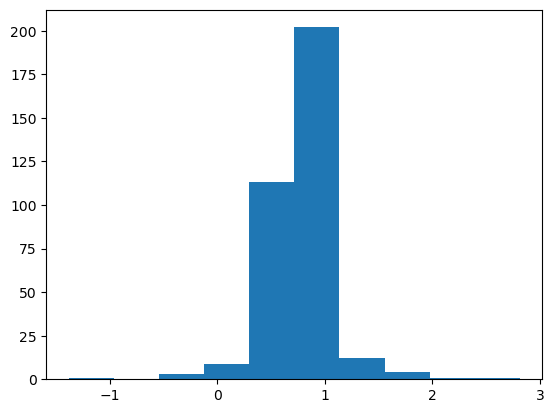

In [31]:
g_r_col = all_results["Abs Mag"][all_results["band"] == "g"]- all_results["Abs Mag"][all_results["band"] == "r"]
plt.hist(g_r_col)

In [32]:
# res_fl = all_results.group_by(keys=["Galaxy Name", "band", "Function Label"])
gal_col = all_results.group_by(keys=["Galaxy Name", "Function Label", "Galaxy Type"])
gal_col = gal_col["Abs Mag", "Galaxy Name", "Function Label", "Galaxy Type"].groups.aggregate(np.subtract)
gal_col["G-R"] = gal_col["Abs Mag"]
# print(all_results["Flux", "Galaxy Name", "band", "Function Label"][:200])
# print(all_results["Abs Mag", "Galaxy Name", "band", "Function Label"])

In [33]:
print(SGAtable[SGAtable["GALAXY"] == "PGC399039"]["SGA_ID"])
TRACTOR[TRACTOR["SGA_ID"] == 612705]["EBV"]
TRACTOR[TRACTOR["SGA_ID"] == 612705]["GAIA_A_G_VAL"]
-2.5*np.log10(TRACTOR[TRACTOR["SGA_ID"] == 612704]["MW_TRANSMISSION_G"])

SGA_ID
------
612705


0.10973723


In [34]:
sga_appmagcorr_g = SGAtable["G_MAG_SB26"] + 2.5*np.log10(TRACTOR["MW_TRANSMISSION_G"])
sga_appmagcorr_r = SGAtable["R_MAG_SB26"] + 2.5*np.log10(TRACTOR["MW_TRANSMISSION_R"])
sga_col = sga_appmagcorr_g - sga_appmagcorr_r

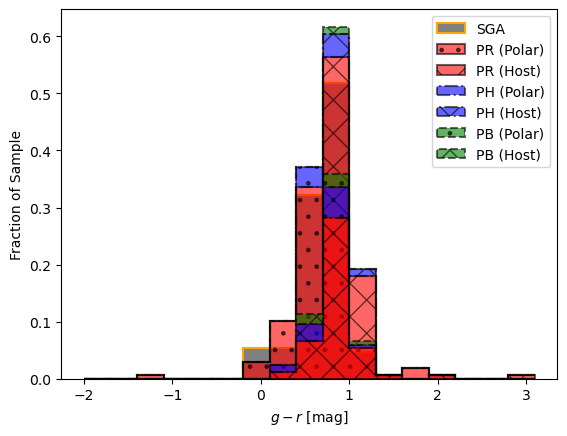

In [35]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-2, 3)
step = 0.3
bins = np.arange(r[0], r[1]+step, step) * u.ABmag

sgaval, bins = np.histogram(sga_col, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    # polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_col = gal_col[(gal_col["Function Label"] == "Polar") & (gal_col["Galaxy Type"] == gal_type)]
    host_col = gal_col[(gal_col["Function Label"] == "Host") & (gal_col["Galaxy Type"] == gal_type)]


    polval, bins = np.histogram(polar_col["G-R"], bins=bins)
    plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    baseline_polar += polval/ngals

    # hostval, bins = np.histogram(host_r26, bins=bins)
    hostval, bins = np.histogram(host_col["G-R"], bins=bins)
    plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    baseline_host += hostval/ngals

plt.xlabel(r"$g-r$ [mag]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

### Sersic Index (in $r$ band)

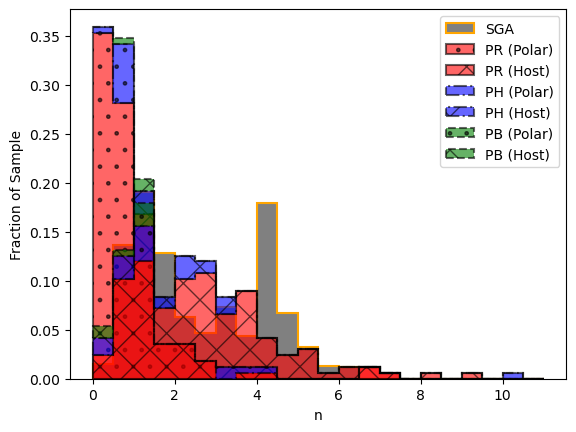

In [36]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (0, 11)
step = 0.5
bins = np.arange(r[0], r[1]+step, step)

sgaval, bins = np.histogram(TRACTOR["SERSIC"], bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]


    polval, bins = np.histogram(polar["n"], bins=bins)
    plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    baseline_polar += polval/ngals

    hostval, bins = np.histogram(host["n"], bins=bins)
    plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    baseline_host += hostval/ngals

plt.xlabel(r"n")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

### Color-Color for Host and Polar Structure

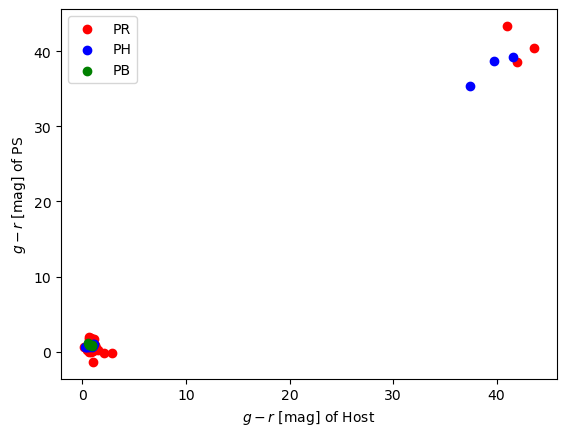

In [37]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-2, 3)
step = 0.3
bins = np.arange(r[0], r[1]+step, step) * u.ABmag

# sgaval, bins = np.histogram(sga_col, bins=bins)
# plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    # polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_col = gal_col[(gal_col["Function Label"] == "Polar") & (gal_col["Galaxy Type"] == gal_type)]
    host_col = gal_col[(gal_col["Function Label"] == "Host") & (gal_col["Galaxy Type"] == gal_type)]


    # polval, bins = np.histogram(polar_col["G-R"], bins=bins)
    # plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    # baseline_polar += polval/ngals

    # # hostval, bins = np.histogram(host_r26, bins=bins)
    # hostval, bins = np.histogram(host_col["G-R"], bins=bins)
    # plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    # baseline_host += hostval/ngals

    plt.scatter(host_col["G-R"], polar_col["G-R"], label=gal_type, color=type_colors[gal_type])

plt.xlabel(r"$g-r$ [mag] of Host")
plt.ylabel(r"$g-r$ [mag] of PS")
# plt.xlim([0,3])
# plt.ylim([0,3])
plt.legend()
plt.show()

### Color Magnitude

In [40]:
band_group = all_results.group_by(keys=["Galaxy Name", "Galaxy Type", "band", "A", "KCOR", "z", "DL"])
band_group = band_group["Galaxy Name", "Galaxy Type", "band", "Flux", "A", "KCOR", "z", "DL"].groups.aggregate(np.sum)

band_group["App Mag"] = flux2ABmag(band_group["Flux"] * u.nmgy).value
band_group["Abs Mag"] = band_group["App Mag"] - astropy.coordinates.Distance(band_group["DL"]).distmod.value
band_group["Abs Mag Corr"] = band_group["Abs Mag"] - band_group["A"] - band_group["KCOR"]

band_group_col = band_group.group_by(keys=["Galaxy Name", "Galaxy Type"])
band_group_col = band_group_col["Galaxy Name", "Galaxy Type", "Abs Mag Corr"].groups.aggregate(np.subtract)
band_group_col["G-R"] = band_group_col["Abs Mag Corr"]

In [50]:
type_marker = {
    "PR": "o",
    "PH": "D",
    "PB": "^"
}

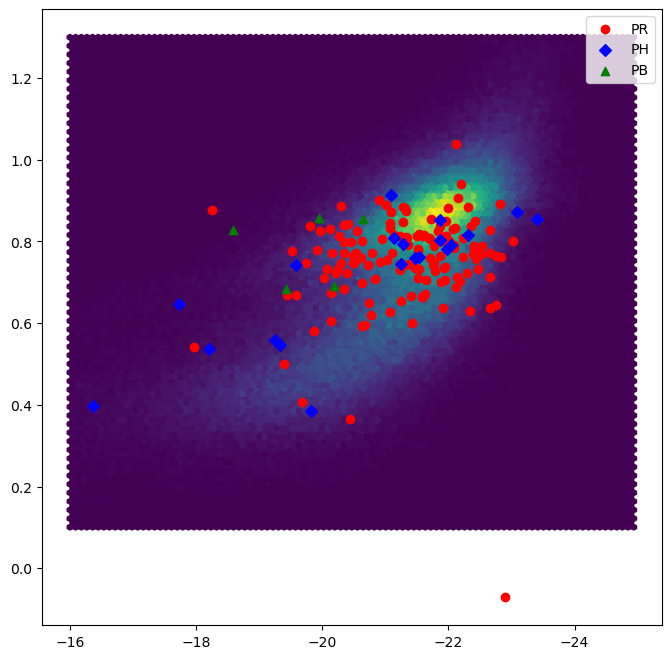

In [51]:
fig = plt.figure(figsize=(8,8), dpi=100)


m = (SGAtable["Z_LEDA"] > 0) & (SGAtable["R_MAG_SB26"] != -1)
m2 = (SGAtable["Z_LEDA"] > 0) & (SGAtable["G_MAG_SB26"] != -1)
m3 = (SGAtable["R_ABSMAG_SB26"] < -16) & (SGAtable["R_ABSMAG_SB26"] > -25) & (sga_col > 0.1) & (sga_col < 1.3)

plt.hexbin(SGAtable["R_ABSMAG_SB26"][m & m3], sga_col[m & m3], gridsize=100)

for gal_type in gal_types:
    m = (band_group["band"] == "r") 
    m2 = (band_group["Galaxy Type"] == gal_type)
    plt.scatter(band_group["Abs Mag"][m & m2], band_group_col["G-R"][band_group_col["Galaxy Type"] == gal_type], color=type_colors[gal_type], label=gal_type, marker=type_marker[gal_type])

# plt.scatter(all_results["Abs Mag Corr"])
# # plt.xlim([-15, -25])
# # plt.ylim([0.2, 1.2])
ax = plt.gca()
ax.xaxis.set_inverted(True)
plt.legend()
plt.show()